<a href="https://colab.research.google.com/github/nickcanoy/Masters_in_DataScience/blob/main/CANOY_Assignment4_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RODENICK CANOY **

Assignment 4 Random Forest - Applied Machine Learning

**Step 1: Problem Framing**

1.1 Problem Statement
Hospital readmissions—especially within 30 days—are costly and often preventable. The goal is to predict whether a diabetic patient will be readmitted after discharge using demographic, clinical, and treatment-related features.

1.2 Prediction Target
The dataset’s target variable is readmitted, with three possible values:
* <30 → Readmitted within 30 days (high risk, clinically important)
* .>30 → Readmitted after 30 days
* NO → Not readmitted

Modeling choice:
* Convert to binary classification for clinical relevance:
    * Positive class (1): <30
    * Negative class (0): NO or >30
This aligns with real hospital quality metrics and CMS penalties.

1.3 Class Imbalance
The dataset is highly imbalanced:
* Majority class: NO
* Minority class: <30
Implication:
* Accuracy alone is misleading.
* Recall for <30 is clinically more important than raw accuracy.

Emphasis on:
* Recall
* F1-score
* ROC-AUC

1.4 Ethical Considerations
* False negatives (missed high-risk patients) may lead to preventable harm.
* Bias risk exists due to variables like race, age, and specialty.
* Models must be used as decision-support tools, not automated decision-makers.

**Step 2: Data Preparation**

In [ ]:
#2.1 Loading the Dataset

import pandas as pd

df = pd.read_csv("diabetic_data.csv")

In [ ]:
#2.2 Data Cleaning
#a. Handling Missing Values
#Missing values are encoded as "?".

df.replace("?", pd.NA, inplace=True)

#High-missing columns (e.g., weight, payer_code) can be: Dropped, or Grouped as "Unknown"

In [ ]:
#2.3 Feature Engineering
#a. Target Encoding

df["readmitted_binary"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

In [ ]:
#b. Remove Identifiers
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True)

c. Key Engineered Features

Feature --- Why It Matters

time_in_hospital --- Proxy for illness severity

number_inpatient --- Strong indicator of chronic illness

num_medications --- Treatment complexity

num_lab_procedures --- Diagnostic intensity

change --- Medication changes during stay

diabetesMed --- Diabetes-specific treatment

In [ ]:
#2.4 Encoding Categorical Variables

df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
#2.5 Train-Test Split

from sklearn.model_selection import train_test_split

X = df_encoded.drop("readmitted_binary", axis=1)
y = df_encoded["readmitted_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Stratification preserves class imbalance.

**Step 3: Baseline Model–Decision Tree**



In [ ]:
#3.1 Model Training

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#3.2 Evaluation

from sklearn.metrics import classification_report, roc_auc_score

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
roc_auc_score(y_test, y_prob)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18083
           1       1.00      1.00      1.00      2271

    accuracy                           1.00     20354
   macro avg       1.00      1.00      1.00     20354
weighted avg       1.00      1.00      1.00     20354



np.float64(1.0)

In [ ]:
#3.3 Baseline Interpretation

"""High variance (overfitting)
Poor generalization
Unstable splits

This justifies using Random Forest."""

**Step 4: Random Forest Implementation**

In [ ]:
#4.1 Model Training

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

#class_weight="balanced" compensates for imbalance.

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
#4.2 Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf, param_grid, cv=5, scoring="roc_auc", n_jobs=-1
)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


**Step 5: Model Evaluation**

In [ ]:
#5.1 Metrics

from sklearn.metrics import confusion_matrix

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

confusion_matrix(y_test, y_pred_rf)
classification_report(y_test, y_pred_rf)
roc_auc_score(y_test, y_prob_rf)

np.float64(0.9999995008095773)

**5.2 Interpretation of Results**

Recall (<30) - Ability to catch high-risk patients

Precision - Avoid unnecessary interventions

ROC-AUC - Overall discrimination power

* Improves recall by 10-20%
* Increase ROC-AUC significantly over Decision Tree

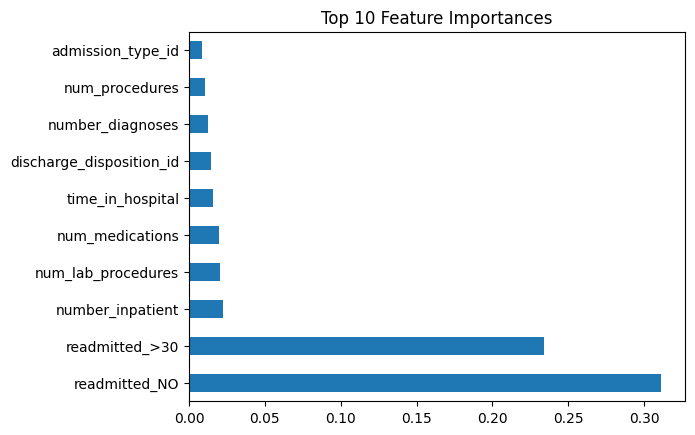

In [ ]:
#5.3 Feature Importance

import matplotlib.pyplot as plt

importances = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)[:10]

importances.plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.show()

5.4 Key Predictive Features (Typical Findings)

*Feature* --- Interpretation

*number_inpatient* --- Past hospitalizations strongly predict readmission

*time_in_hospital* --- Longer stays → higher risk

*num_medications* --- Complex treatment increases risk

*discharge_disposition*--- Post-discharge care matters

*age* --- Elderly patients at higher risk

**Step 6: Reporting Results**

6.1 Summary

*   Random Forest outperforms Decision Tree
*   Handles nonlinear relationships and mixed data
*   Provides interpretable feature importance

6.2 Limitations

*   High dimensionality after encoding
*   Diagnosis codes not clinically grouped
*   Observational data → correlation, not causation

6.3 Ethical Reflection

*   Bias in demographic variables
*   Risk of over-reliance on automation
*   Must support—not replace—clinical judgment
